# Hypergraph Concept Lattices Tutorial

This tutorial demonstrates how to construct the concept lattice of a hypergraphs incidence relation.

Please install the following for this notebook to run:

* bitsets

In [2]:
import hypernetx as hnx
import hypernetx.algorithms.concepts as hlat
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

## 1) Hypergraph Concept Lattices

We begin with a small example of a hypergraph below.

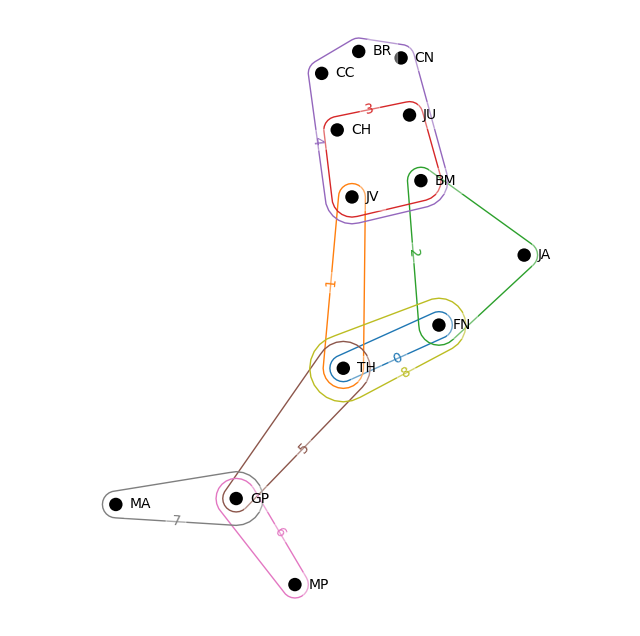

In [3]:
scenes_dictionary = {
    '0': ('FN', 'TH'),
    '1': ('TH', 'JV'),
    '2': ('BM', 'FN', 'JA'),
    '3': ('JV', 'JU', 'CH', 'BM'),
    '4': ('JU', 'CH', 'BR', 'CN', 'CC', 'JV', 'BM'),
    '5': ('TH', 'GP'),
    '6': ('GP', 'MP'),
    '7': ('MA', 'GP'),
    '8': ('FN', 'TH')
}

H = hnx.Hypergraph(scenes_dictionary)
hnx.draw(H)

A hypergraph is equivalently defined its incidence relation *I*  shown below. It is from this relation that the concept lattice is defined.

In [4]:
display(H.incidence_dataframe())

,0,1,2,3,4,5,6,7,8
BM,0,0,1,1,1,0,0,0,0
BR,0,0,0,0,1,0,0,0,0
CC,0,0,0,0,1,0,0,0,0
CH,0,0,0,1,1,0,0,0,0
CN,0,0,0,0,1,0,0,0,0
FN,1,0,1,0,0,0,0,0,1
GP,0,0,0,0,0,1,1,1,0
JA,0,0,1,0,0,0,0,0,0
JU,0,0,0,1,1,0,0,0,0
JV,0,1,0,1,1,0,0,0,0


Given a subset of vertices $A \subseteq V$ we may obtain a subset of hyperedges $A' \subseteq E$ where
$$A' := \{ e \in E \mid \forall v \in A, \, I(v,e) = 1 \}.$$
On the other hand, given a subset of edges $B \subseteq E$ we may obtain a subset of vertices $B' \subseteq V$ by
$$B' := \{ v \in V \mid \forall e \in B, \, I(v,e) = 1\}.$$
A pair of subsets $(A,B)$ is a *concept* if $A' = B$ and $B' = A$. The set of concepts inherits a partial order by defining $(A,B) \leq (C,D)$ whenever $A \subseteq C$ or, equivalently, $D \subseteq B$. It is a fundamental theorem that the set of concepts is not only a partially ordered set, but a complete lattice.

One may think of the concept lattice as a heirarchical set of 'clusters' of vertices or edges. We list all of the elements of the lattice (with their indices) below where each element is a pair of (possibly empty) tuples: the *extent* (tuple of vertices) and the *intent* (tuple of hyperedges). 

In [5]:
hg_lat = hlat.HypergraphLattice(H)
concept_indices = nx.get_node_attributes(hg_lat.digraph, 'concept').items()
for pair in concept_indices:
    print(pair[0], pair[1])

0 {} : [0, 1, 2, 3, 4, 5, 6, 7, 8]
1 {BM} : [2, 3, 4]
2 {FN} : [0, 2, 8]
3 {GP} : [5, 6, 7]
4 {JV} : [1, 3, 4]
5 {TH} : [0, 1, 5, 8]
6 {FN, TH} : [0, 8]
7 {GP, MA} : [7]
8 {GP, MP} : [6]
9 {GP, TH} : [5]
10 {JV, TH} : [1]
11 {BM, FN, JA} : [2]
12 {BM, CH, JU, JV} : [3, 4]
13 {BM, BR, CC, CH, CN, JU, JV} : [4]
14 {BM, BR, CC, CH, CN, FN, GP, JA, JU, JV, MA, MP, TH} : []


**Note that the labels on nodes and edges must be strings in order to construct the lattice object.** 

## 2) Drawing the Concept Lattice

The concept lattice of the above example is drawn below. Make note of the the special arguments for labelling concepts.

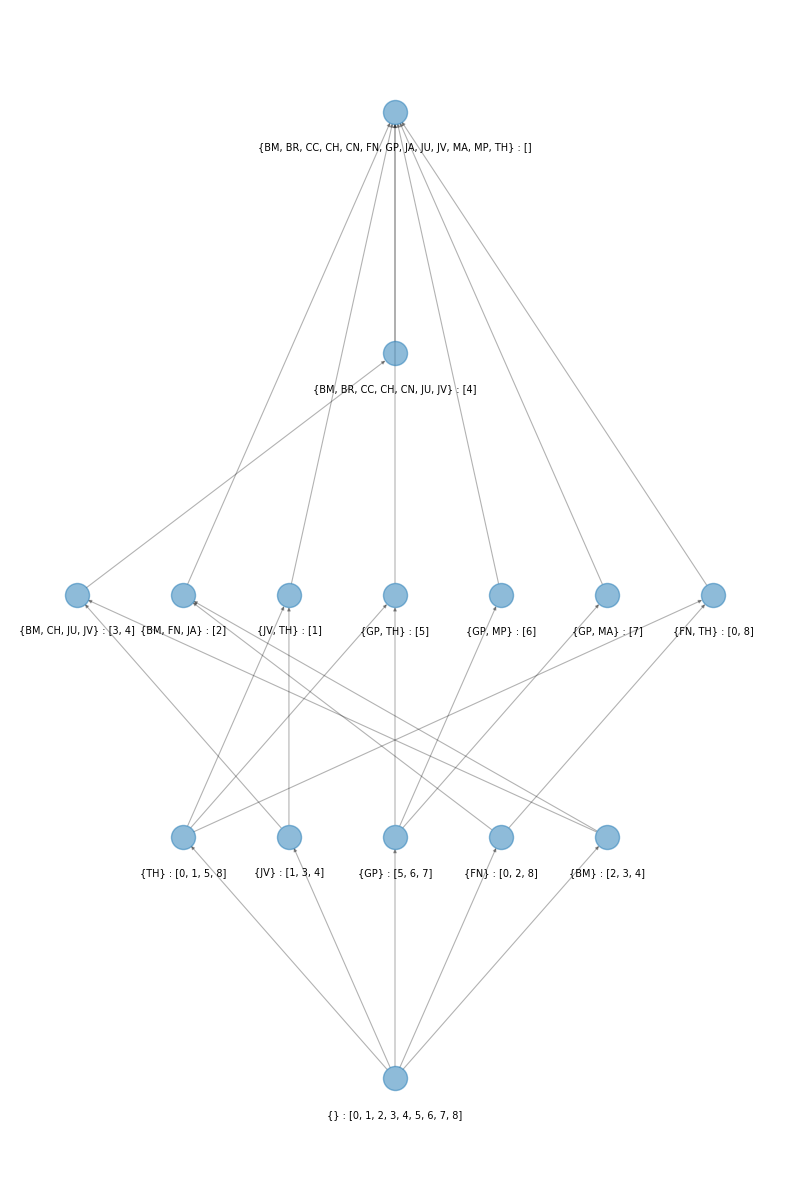

In [6]:
plt.figure(figsize = (8,12))
hg_lat.draw_lattice(shortform = False, horizontal = False, font_size = 7, label_offset = 0.05, edge_alpha = 0.3)
plt.tight_layout()

## 3) Lattice Operations

The meet of two elements in the concept lattice is the greatest lower bound:

In [7]:
print(hg_lat.meet([hg_lat[3],hg_lat[6]]))

{} : [0, 1, 2, 3, 4, 5, 6, 7, 8]


The join of two elements in the concept lattice is the least upper bound:

In [8]:
print(hg_lat.join([hg_lat[3],hg_lat[6]]))

{BM, BR, CC, CH, CN, FN, GP, JA, JU, JV, MA, MP, TH} : []


One may also obtain upsets/downsets of concepts:

In [9]:
print('Concept' , hg_lat[5]) 
print('-----')
print('Upset') 
print('-----')
for concept in hg_lat[5].upset():
    print(concept)
print('-------')
print('Downset') 
print('-------')
for concept in hg_lat[5].downset():
    print(concept)

Concept {TH} : [0, 1, 5, 8]
-----
Upset
-----
{TH} : [0, 1, 5, 8]
{FN, TH} : [0, 8]
{GP, TH} : [5]
{JV, TH} : [1]
{BM, BR, CC, CH, CN, FN, GP, JA, JU, JV, MA, MP, TH} : []
-------
Downset
-------
{TH} : [0, 1, 5, 8]
{} : [0, 1, 2, 3, 4, 5, 6, 7, 8]


An *atom* of a lattice is a minimal element which is not the bottom:


In [10]:
for atom in hg_lat.atoms:
    print(atom)

{BM} : [2, 3, 4]
{FN} : [0, 2, 8]
{GP} : [5, 6, 7]
{JV} : [1, 3, 4]
{TH} : [0, 1, 5, 8]


An element is *join irreducbile* if it neither the bttom element nor the join of any two smaller elements.

In [11]:
for concept in hg_lat.join_irreducibles():
    print(concept)

{GP, MP} : [6]
{} : [0, 1, 2, 3, 4, 5, 6, 7, 8]
{GP} : [5, 6, 7]
{GP, MA} : [7]
{BM} : [2, 3, 4]
{FN} : [0, 2, 8]
{BM, BR, CC, CH, CN, JU, JV} : [4]
{JV} : [1, 3, 4]
{TH} : [0, 1, 5, 8]


## 4) Lattice Metrics

In this section we consider metrics $d : L \times L \to \mathbb{R}$ on a lattice $L$. Large classes of poset metrics are induced by *upper valuations* $\mu : L \to \mathbb{R}$, which are monotone functions satisfying $\mu(x \wedge y) + \mu(x \vee y) \leq \mu(x) + \mu(y)$. Every lattice has as an upper valuation given by
$$ \mu(x) := | L \setminus \{k \in L : k \geq x \}|.$$
It can be shown (Leclerc B. 93) that the function 
$$ d(x,y) := 2\mu(x \vee y) - \mu(x) - \mu(y)$$
is always a metric on $L$ for any upper valuation $\mu$. We use this distance below: 

In [12]:
dist = hg_lat.distance(3,5, metric = 'upper_valuation')
print('Concept 1 ', hg_lat[3])
print('Concept 2 ', hg_lat[5])
print('Their upper distance is', dist)

Concept 1  {GP} : [5, 6, 7]
Concept 2  {TH} : [0, 1, 5, 8]
Their upper distance is 6.0


Exploiting the fact the for any lattice $L$ we may form the dual lattice $L^{op}$ with the reverse ordering, there is also a dual notion of this distance:

In [13]:
dist = hg_lat.distance(3,5, metric = 'lower_valuation')
print('Concept 1 ', hg_lat[3])
print('Concept 2 ', hg_lat[5])
print('Their lower distance is', dist)

Concept 1  {GP} : [5, 6, 7]
Concept 2  {TH} : [0, 1, 5, 8]
Their lower distance is 2.0


Below we compute the distance matrices for both the upper and lower distances. Note that since the upset of the bottom element is all of $L$, it tends to be very far from most other elements of the lattice with respect to the upper distance (and dually for the top element and the lower distance).

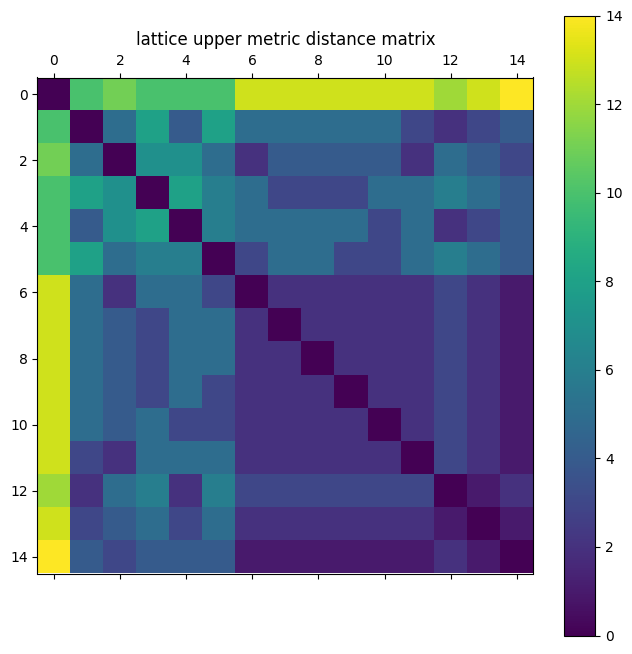

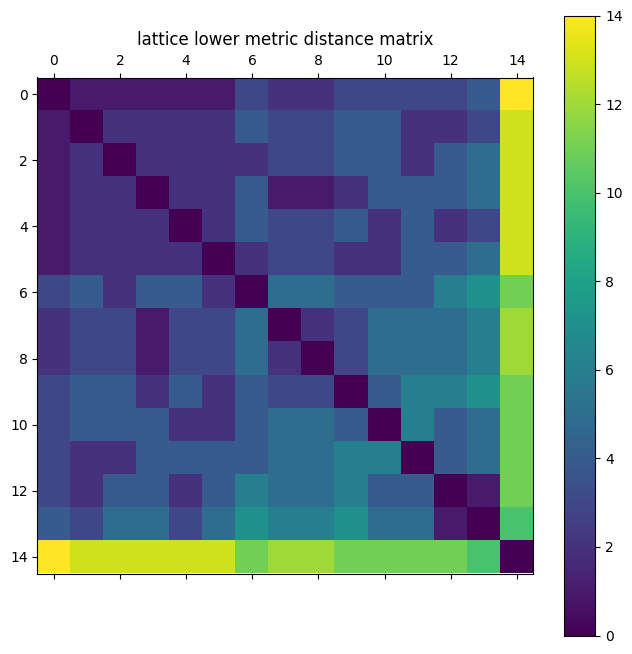

In [14]:
def dist_matrix(dist_dict):
    num_nodes = len(dist_dict)
    d = np.zeros((num_nodes, num_nodes))
    for i in range(num_nodes):
        for j in range(num_nodes):                 
            d[i,j] = dist_dict[i][j]
    return d

d_upper = hg_lat.all_distances(metric = 'upper_valuation')

plt.matshow(dist_matrix(d_upper))
plt.title('lattice upper metric distance matrix')
plt.colorbar()

d_lower = hg_lat.all_distances(metric = 'lower_valuation')

plt.matshow(dist_matrix(d_lower))
plt.title('lattice lower metric distance matrix')
plt.colorbar()

We may also consider the shortest path distance on underlying undirected graph of $L$ (i.e. the Hasse diagram). 

In [15]:
dist = hg_lat.distance(3,5)
print('Concept 1 ', hg_lat[3])
print('Concept 2 ', hg_lat[5])
print('Their path distance is', dist)

Concept 1  {GP} : [5, 6, 7]
Concept 2  {TH} : [0, 1, 5, 8]
Their path distance is 2.0


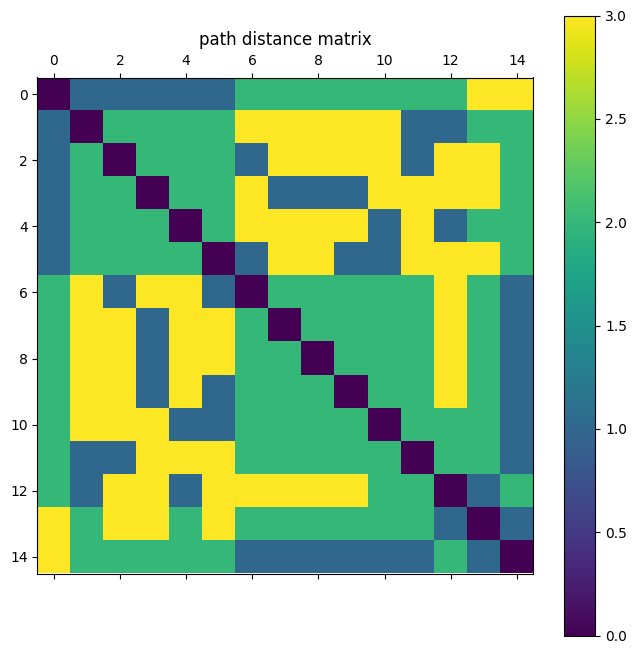

In [16]:
d_path = hg_lat.all_distances()
plt.matshow(dist_matrix(d_path))
plt.title('path distance matrix')
plt.colorbar()

Lower valuations can be induced on the concept lattice from an assignment of positive weights for each vertex. Below we assign the weight 1.0 to each vertex.

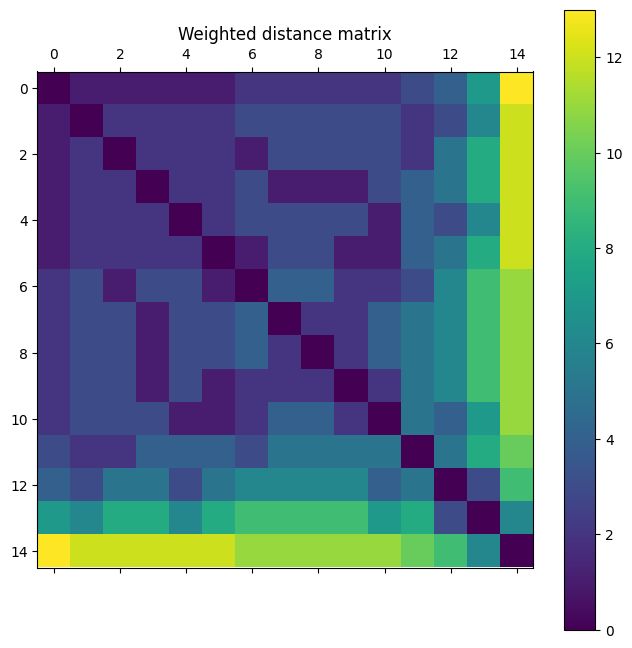

In [17]:
metric = dict([ (vertex,1.0) for vertex in H.incidence_dataframe().index])
d_uniform = hg_lat.all_distances(metric)
plt.matshow(dist_matrix(d_uniform))
plt.title('Weighted distance matrix')
plt.colorbar()